In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('data/california_housing.csv')

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


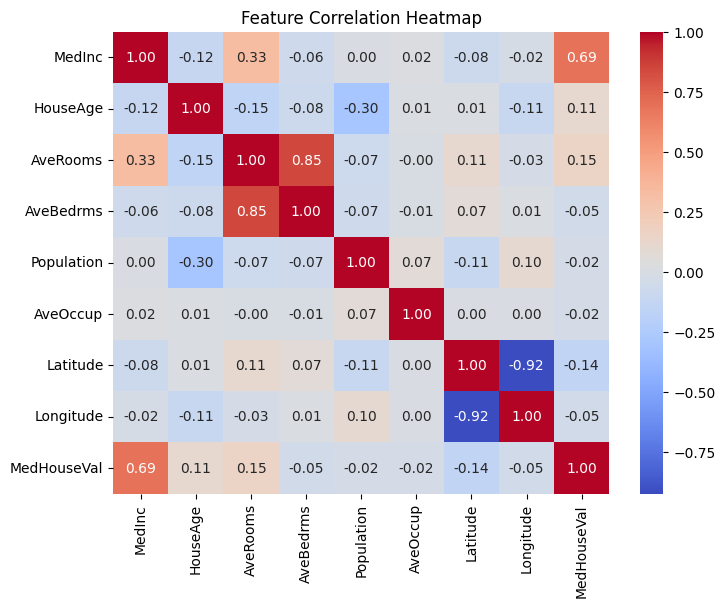

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
corr=df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
x=df.drop('MedHouseVal', axis=1).values
y=df['MedHouseVal'].values
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model=LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)


In [16]:
mse, r2

(0.5558915986952443, 0.5757877060324508)

In [17]:
from sklearn.linear_model import Ridge, Lasso
ridge_model=Ridge(alpha=1.0, random_state=42)
ridge_model.fit(x_train_scaled, y_train)
y_ridge_pred=ridge_model.predict(x_test_scaled)
ridge_mse=mean_squared_error(y_test, y_ridge_pred)
ridge_r2_score=r2_score(y_test, y_ridge_pred)


In [18]:
ridge_mse, ridge_r2_score

(0.5558548589435972, 0.5758157428913682)

In [19]:
lasso_model=Lasso(alpha=0.1, random_state=42)
lasso_model.fit(x_train_scaled, y_train)
y_lasso_pred=lasso_model.predict(x_test_scaled)
lasso_mse=mean_squared_error(y_test, y_lasso_pred)
lasso_r2_score=r2_score(y_test, y_lasso_pred)

In [20]:
lasso_mse, lasso_r2_score

(0.6796290284328821, 0.4813611325029077)

In [21]:
from sklearn.model_selection import GridSearchCV
import numpy as np
alphas=np.logspace(-3, 3, 20)
ridge_model_grid=Ridge(random_state=42)
ridge_cv=GridSearchCV(ridge_model_grid, param_grid={'alpha':alphas}, cv=5, scoring='r2')
ridge_cv.fit(x_train_scaled, y_train)
ridge_cv.best_params_


{'alpha': np.float64(0.001)}

In [22]:
ridge_best=ridge_cv.best_estimator_
y_ridge_best_pred=ridge_best.predict(x_test_scaled)
ridge_best_mse=mean_squared_error(y_test, y_ridge_best_pred)
ridge_best_r2=r2_score(y_test, y_ridge_best_pred)
ridge_best_mse, ridge_best_r2

(0.5558915618350118, 0.5757877341612512)

In [23]:
ridge_best.coef_

array([ 0.85438297,  0.12254632, -0.29440993,  0.33925924, -0.0023077 ,
       -0.04082911, -0.89692811, -0.869841  ])

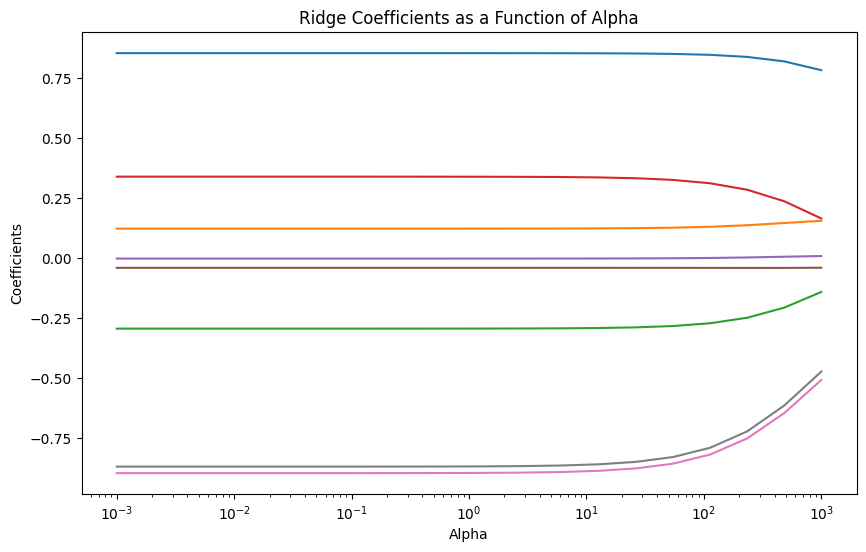

In [24]:
coefs=[]
for a in alphas:
    ridge=Ridge(alpha=a, random_state=42)
    ridge.fit(x_train_scaled, y_train)
    coefs.append(ridge.coef_)
plt.figure(figsize=(10,6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Ridge Coefficients as a Function of Alpha')
plt.show()


In [28]:
lasso_model_grid=Lasso(random_state=42)
lasso_cv=GridSearchCV(lasso_model_grid, param_grid={'alpha':alphas}, cv=5, scoring='r2')
lasso_cv.fit(x_train_scaled, y_train)
lasso_cv.best_params_

{'alpha': np.float64(0.001)}

In [30]:
lasso_best=lasso_cv.best_estimator_
y_lasso_best_pred=lasso_best.predict(x_test_scaled)
lasso_best_mse=mean_squared_error(y_test, y_lasso_best_pred)
lasso_best_r2=r2_score(y_test, y_lasso_best_pred)
lasso_best_mse, lasso_best_r2

(0.5544913600832686, 0.5768562568705682)

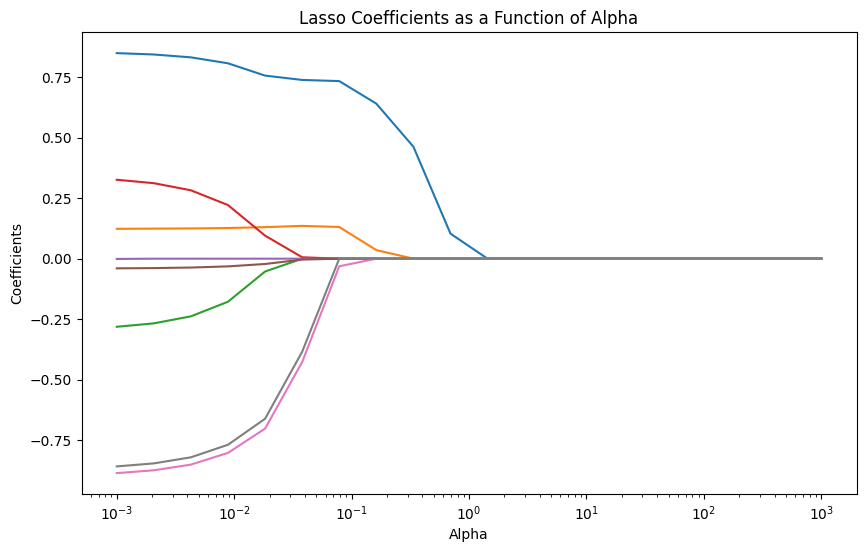

In [31]:
coefs_lasso=[]
for a in alphas:
    lasso=Lasso(alpha=a, random_state=42)
    lasso.fit(x_train_scaled, y_train)
    coefs_lasso.append(lasso.coef_)
plt.figure(figsize=(10,6))
plt.plot(alphas, coefs_lasso)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficients as a Function of Alpha')
plt.show()

In [26]:
ridge_test=Ridge(alpha=1000, random_state=42)
ridge_test.fit(x_train_scaled, y_train)
ridge_test.coef_.sort()
ridge_test.coef_

array([-0.50842148, -0.47349611, -0.14147497, -0.04043909,  0.00828657,
        0.1551494 ,  0.16484629,  0.78331979])

In [ ]:
test_pred=ridge_test.predict(x_test_scaled)
mean_squared_error(y_test, test_pred)

3.4135689473022857

In [32]:
results=pd.DataFrame({
    'Model':['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE':[mse, ridge_best_mse, lasso_best_mse],
    'R2 Score':[r2, ridge_best_r2, lasso_best_r2]
})
results

,Model,MSE,R2 Score
0,Linear Regression,0.555892,0.575788
1,Ridge Regression,0.555892,0.575788
2,Lasso Regression,0.554491,0.576856
